# Event-Based Cameras
### Understanding the data SNN will process

**What I learned here**
1. What an event camera is
2. The event data format - what you actually get out of one
3. Loading real neuromorphic data with the `tonic` library
4. Visualizing events - seeing what the camera 'sees'
5. Representations - converting raw events into something an SNN can process
6. Why event cameras and SNNs are a natural match

---

## Setup - Install Required Libraries

Run this once in the terminal before starting:
```bash
pip install tonic matplotlib numpy torch
```

`tonic` is the standard library for loading neuromorphic / event-based datasets. It works like PyTorch's `torchvision` but for spike data.

In [2]:
import tonic
import tonic.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print("tonic version:", tonic.__version__)
print("All imports OK!")

tonic version: 1.6.0
All imports OK!


---
## Part 1 - What Is an Event Camera?

### The problem with normal cameras

A standard (frame-based) camera takes a snapshot every 1/30th of a second. Every pixel captures brightness at the same moment. This gives you a beautiful image — but it has real problems:

- **Motion blur** - fast-moving objects smear across the frame
- **Wasted data** - if nothing moves, you're capturing the same image over and over
- **Latency** - you wait for the next frame even if something important just happened
- **High dynamic range issues** - can't handle both bright and dark regions well simultaneously

### How an event camera works differently

An event camera has no concept of a 'frame'. Instead, **each pixel acts independently**:

> Each pixel fires an **event** the moment it detects a change in brightness.

```
Event cameras are neuromorphic sensors - they mimic how biological retinas work. Each photoreceptor in your eye fires spikes based on change, not absolute brightness. This makes event cameras a natural hardware partner for SNNs, and for spiking NanoLED hardware:

```
Event Camera (spikes in) → SNN (spike processing) → NanoLED hardware (spike output)
```


---
## Part 2 - The Event Data Format

Every event has exactly 4 values:

| Field | Type | Meaning |
|-------|------|---------|
| `x` | int | Pixel column (horizontal position) |
| `y` | int | Pixel row (vertical position) |
| `t` | int | Timestamp in **microseconds** |
| `p` | int | Polarity: `1` = brightness increased, `0` = brightness decreased |

So a single event looks like: `(x=34, y=12, t=1040523, p=1)` - pixel at column 34, row 12 got brighter at timestamp 1,040,523 microseconds.

A scene with some motion might generate **millions of events per second**, while a static scene generates almost **zero events**. This sparsity is a core property- and a big efficiency advantage.

In Python/numpy, events are stored as a **structured array** where each element has these 4 named fields.

In [16]:
# Load N-MNIST — the neuromorphic version of MNIST
# A DVS camera was moved in front of static MNIST digits, generating events
# This gives us a simple, well-understood dataset to start with

# tonic will automatically download the dataset on first run (~50MB)
dataset = tonic.datasets.NMNIST(
    save_to='./data',   # where to save the downloaded data
    train=True          # training split
)

print(f"Dataset: {dataset}")
print(f"Number of samples: {len(dataset)}")
print(f"Sensor size (W x H x Polarities): {dataset.sensor_size}")

Dataset: NMNIST
Number of samples: 60000
Sensor size (W x H x Polarities): (34, 34, 2)


In [4]:
# Playing around to understand how the data looks like

# print(dataset[0]) # dataset[0] corresponds to the entire first digit recording
# dataset[0] looks like following (array([(10, 30,    937, 1), (33, 20,   1030, 1),... ],dtype=[('x', '<i4'), ('y', '<i4'), ('t', '<i4'), ('p', '<i4')]), 0)

# outer () -> Dataset sample containing the events and the label
# array() -> container for all the spikes
# []-> list of all the spikes
# (10,30,937,1)-> A single packet of spiking event data


events, label = dataset[0] #events -- list of all spikes 

# Look at the FIRST individual spike in that sample
first_spike = events[0]

# 3. This is where you see the (x, y, t, p)
print(first_spike) 
# Output will look something like: (12, 25, 1040, 1)

# How many spikes are in this one digit?
print(len(events)) 
# We see that we have captured about 5028 spikes for the single digit.

# Get only the timestamps to see how fast the '0' was moving
print(events['t']) 

print(f"Label (digit): {label}")
print(f"\nEvent array type: {type(events)}")
print(f"Number of events: {len(events)}")
print(f"Fields in each event: {events.dtype.names}")



(10, 30, 937, 1)
5028
[   937   1030   1052 ... 302706 303852 305341]
Label (digit): 0

Event array type: <class 'numpy.ndarray'>
Number of events: 5028
Fields in each event: ('x', 'y', 't', 'p')


In [5]:
# Look at the first 5 events
print("\nFirst 5 events:")
print(f"{'x':>6} {'y':>6} {'t':>12} {'p':>6}")
print("-" * 35)
for i in range(5):
    e = events[i]
    print(f"{e['x']:>6} {e['y']:>6} {e['t']:>12} {e['p']:>6}")

# Time span of this event sequence
duration_ms = (events['t'][-1] - events['t'][0]) / 1000
print(f"\nTime span: {duration_ms:.1f} ms")
print(f"Events per ms: {len(events)/duration_ms:.0f}")


First 5 events:
     x      y            t      p
-----------------------------------
    10     30          937      1
    33     20         1030      1
    12     27         1052      1
    33      3         2078      1
    14     23         2383      0

Time span: 304.4 ms
Events per ms: 17


In [6]:
from collections import Counter

# dataset.targets is a list of all labels (e.g., [0, 5, 2, 8, ...])
label_counts = Counter(dataset.targets)

print("Distribution of labels in N-MNIST:")
# We sort by key (0, 1, 2...) so the output is easy to read
for label in sorted(label_counts.keys()):
    print(f"Digit {label}: {label_counts[label]} samples")

# Interesting!! I expected that the number of each sample to be the same --- but apparently, that doesn't seemt to be the case here. 


Distribution of labels in N-MNIST:
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples


In [7]:
# This prints the labels of desired members of the dataset
print(f"labels: {dataset.targets[45000:50000]}")

labels: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7

---
## Part 3 - Visualising Events by plots

Raw events are a list of (x, y, t, p) tuples — hard to picture mentally. Let's visualise them in a few ways to build intuition.

### Approach 1 - Scatter plot by time
Plot each event as a dot at its (x, y) position, coloured by timestamp. You should see the digit shape emerge, with temporal structure.

### Approach 2 - Polarity separation
Show positive events (ON) and negative events (OFF) separately — red for ON, blue for OFF.

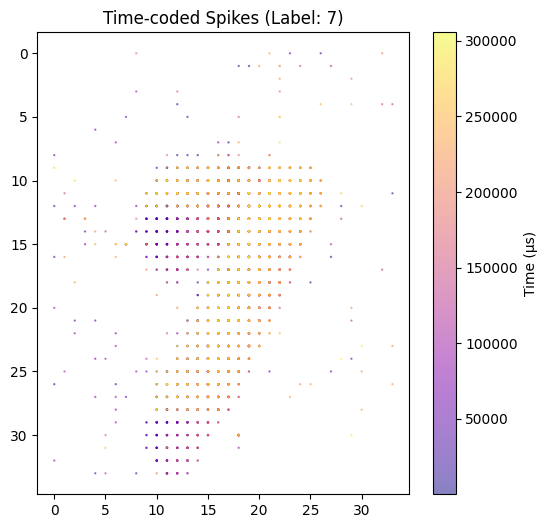

In [8]:
# Approach 1: Scatter plot by time

# Scatter plot by time helps us visualize how the event camera was moved to capture the image.
# purple dots - captured early; yellow dotes - captured later;

events, label = dataset[48000] # 50,000 th image in the data set
plt.figure(figsize=(6, 6))
# We use 'c' to map the time to a color so we can see the "flow"
plt.scatter(events['x'], events['y'], c=events['t'], cmap='plasma',
    s=0.5, alpha=0.5) # s --> size of individual spikes; alpha--> trasparency of individual spikes
plt.title(f"Time-coded Spikes (Label: {label})")
plt.gca().invert_yaxis() # Flip so it's not upside down
plt.colorbar(label="Time (μs)")
plt.show()

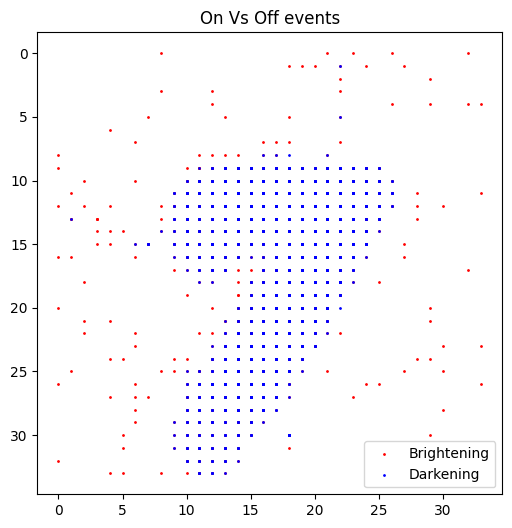

In [9]:
# Approach 2: Polarity Seperation

events, label = dataset[48000] # 48,000 th image in the data set
plt.figure(figsize=(6, 6))
on = events[events['p'] == 1]
off = events[events['p'] == 0]

plt.scatter(on['x'], on['y'], color='red', s=1, label='Brightening')
plt.scatter(off['x'], off['y'], color='blue', s=1, label='Darkening')
plt.legend()
plt.gca().invert_yaxis()
plt.title("On Vs Off events")
plt.show()

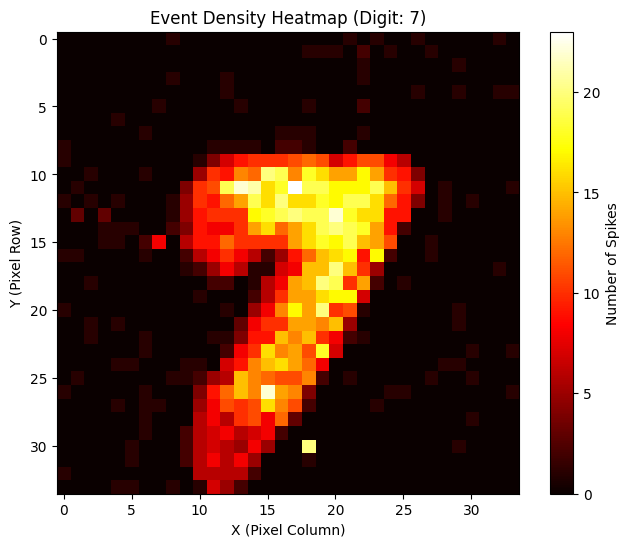

In [10]:
# Visualizing the event density

import numpy as np

# 1. Get the data
events, label = dataset[48000]
W, H = dataset.sensor_size[0], dataset.sensor_size[1]

# 2. Create the empty grid
heatmap = np.zeros((H, W))

# 3. Fill the grid (The line you asked about)
for e in events:
    heatmap[e['y'], e['x']] += 1

# 4. Plotting
plt.figure(figsize=(8, 6))
# 'hot' cmap makes high-density areas look white/yellow and low-density red/black
im = plt.imshow(heatmap, cmap='hot', origin='upper')

plt.colorbar(im, label='Number of Spikes')
plt.title(f"Event Density Heatmap (Digit: {label})")
plt.xlabel("X (Pixel Column)")
plt.ylabel("Y (Pixel Row)")

plt.show()

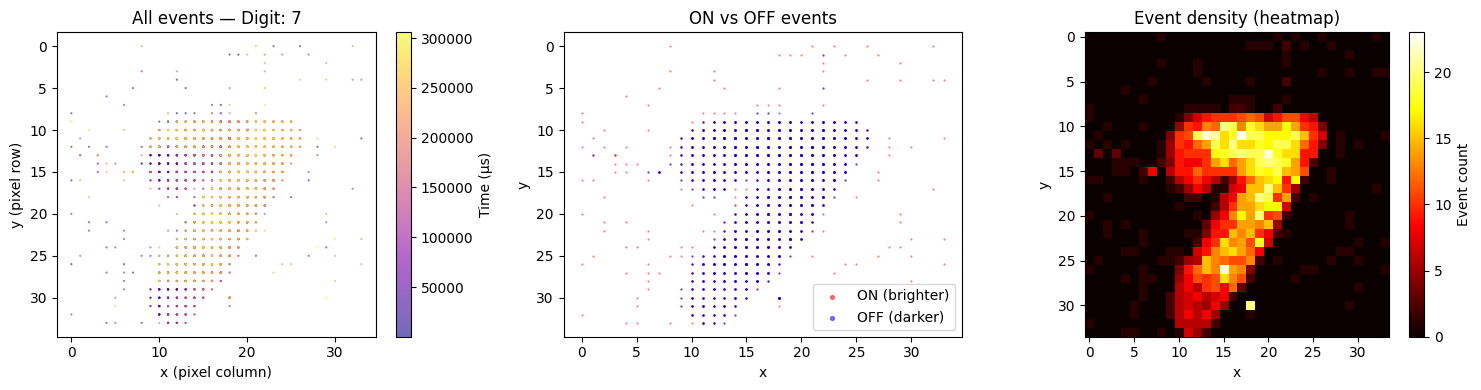

Saved to ./data/event_visualization.png


In [17]:
# Bringing it all together - time, on-off, density
events, label = dataset[48000]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: All events coloured by time ---
sc = axes[0].scatter(
    events['x'], events['y'],
    c=events['t'],          # colour = timestamp
    cmap='plasma',
    s=0.3, alpha=0.6
)
plt.colorbar(sc, ax=axes[0], label='Time (μs)')
axes[0].set_title(f'All events — Digit: {label}')
axes[0].set_xlabel('x (pixel column)')
axes[0].set_ylabel('y (pixel row)')
axes[0].invert_yaxis()  # image convention: y=0 at top

# --- Plot 2: ON events (polarity=1) ---
on_events  = events[events['p'] == 1]
off_events = events[events['p'] == 0]

axes[1].scatter(on_events['x'],  on_events['y'],  c='red',  s=0.3, alpha=0.5, label='ON (brighter)')
axes[1].scatter(off_events['x'], off_events['y'], c='blue', s=0.3, alpha=0.5, label='OFF (darker)')
axes[1].set_title('ON vs OFF events')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].invert_yaxis()
axes[1].legend(markerscale=5)

# --- Plot 3: Event count per pixel (like a heatmap) ---
W, H = dataset.sensor_size[0], dataset.sensor_size[1]
heatmap = np.zeros((H, W))
for e in events:
    heatmap[e['y'], e['x']] += 1

im = axes[2].imshow(heatmap, cmap='hot', origin='upper')
plt.colorbar(im, ax=axes[2], label='Event count')
axes[2].set_title('Event density (heatmap)')
axes[2].set_xlabel('x'); axes[2].set_ylabel('y')

plt.tight_layout()
plt.savefig('./data/event_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved to ./data/event_visualization.png")


---
## Part 4 - Event Representations

Raw events `(x, y, t, p)` are sparse and asynchronous - great for the real world, but neural networks (even SNNs) usually expect a structured tensor input. We need to convert events into a fixed-size tensor.

Here are the 3 most common representations:

### 1. Event Frame (simplest)
Divide the event stream into N equal time bins. In each bin, count how many ON and OFF events occurred at each pixel. Result: a tensor of shape `[N_bins, 2, H, W]`.

Think of it as: **a short clip, where each 'frame' is a count of events**.

### 2. Time Surface
For each pixel, store the timestamp of the most recent event. Decays exponentially over time. Captures the 'age' of each pixel's last activity. Good for motion understanding.

### 3. Voxel Grid
Like event frames but a smoother representation which distributes weight of a spike among neighbouring bins.

NB: For SNNs, **event frames** are the most natural starting point - each time bin naturally becomes a timestep.

In [18]:
# tonic makes representation conversion very easy with transforms
# its like torchvision.transforms of conventional computer vision.

sensor_size = tonic.datasets.NMNIST.sensor_size  # (34, 34, 2) for N-MNIST
# sensor_size -- defines the co-ordinate boundary

# --- Representation 1: Event Frames ---

# Divides the event stream into n equal time bins
# Each bin accumulates events into a 2D map (one channel per polarity)
# We create the skeleton for converting the raw stream into tensor.
frame_transform = transforms.ToFrame(
    sensor_size=sensor_size,
    n_time_bins=10   # divide the event stream into 10 time windows
)

# Convert the event stream into a tensor.
frames = frame_transform(events) 
print("Event frames shape:", frames.shape)
# Expected: [10, 2, 34, 34]

# [time_bins, polarities, height, width]
print("  time_bins  :", frames.shape[0], " ← 10 snapshots in time")
print("  polarities :", frames.shape[1], " ← ON events and OFF events")
print("  height     :", frames.shape[2])
print("  width      :", frames.shape[3])

Event frames shape: (10, 2, 34, 34)
  time_bins  : 10  ← 10 snapshots in time
  polarities : 2  ← ON events and OFF events
  height     : 34
  width      : 34


In [24]:
# Playing around a bit with the frames tensor

# frames[Bin, Channel, Row, Column] -- frames is a 4D tensor
# In our case that would be frames[10,2,34,34]

# Grab the very first time bin (Snapshot 0)
# This will be shape [2, 34, 34]
first_snapshot = frames[0]

# Grab only the "ON" channel across ALL time bins
# We use ':' for time, and '1' for the ON polarity
# This will be shape [10, 34, 34]
all_on_events = frames[:, 1]

# Grab a specific pixel's history
# How many ON spikes happened at pixel (20, 15) over the whole 10 bins?
pixel_history = frames[:, 1, 20, 15] 
print("Spike counts over time for pixel (20,15):", pixel_history)





Spike counts over time for pixel (20,15): [0 3 1 0 0 0 0 0 0 0]


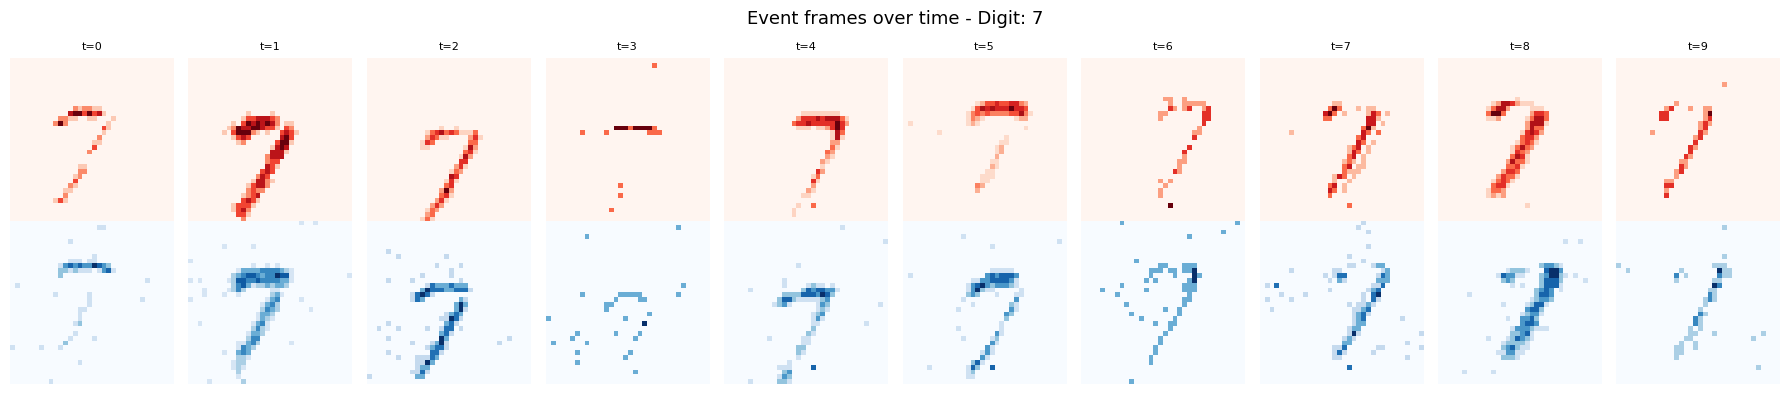

This is what SNN will see - a sequence of event snapshots over time.


In [26]:
# Visualise the 10 time bins as a sequence
# Each bin shows: ON events (red channel) and OFF events (blue channel)

fig, axes = plt.subplots(2, 10, figsize=(18, 4)) # 2 rows (one for each channel), 10 rows(one for each bin)
fig.suptitle(f'Event frames over time - Digit: {label}', fontsize=13)

for t in range(10):
    on_frame  = frames[t, 0]   # polarity 0 = ON in N-MNIST
    off_frame = frames[t, 1]   # polarity 1 = OFF
    
    axes[0, t].imshow(on_frame,  cmap='Reds',  vmin=0)
    axes[1, t].imshow(off_frame, cmap='Blues', vmin=0)
    
    axes[0, t].set_title(f't={t}', fontsize=8)
    axes[0, t].axis('off')
    axes[1, t].axis('off')

axes[0, 0].set_ylabel('ON', fontsize=9)
axes[1, 0].set_ylabel('OFF', fontsize=9)

plt.tight_layout()
plt.savefig('./data/event_frames.png', dpi=120, bbox_inches='tight')
plt.show()
print("This is what SNN will see - a sequence of event snapshots over time.")

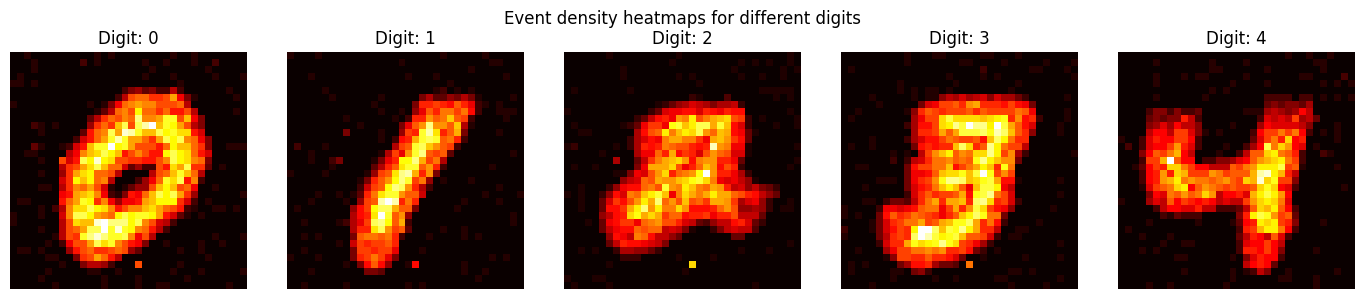

In [ ]:
# Let's look at a few different digits to build intuition
# From the heat maps we can see where the spiking intensity is the highest
# I assume these may be the places where most of the learning is happening

# We'll find one sample of each digit 0-4

# Find indices of specific digits
samples_per_digit = {}   # dict: digit → event array
for i in range(len(dataset)):
    evs, lbl = dataset[i]
    if lbl not in samples_per_digit:
        samples_per_digit[lbl] = evs
    if len(samples_per_digit) == 5:   # stop once we have digits 0-4
        break

# Show the event density heatmap for each digit
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
fig.suptitle('Event density heatmaps for different digits', fontsize=12)

for digit, evs in sorted(samples_per_digit.items()):
    heatmap = np.zeros((34, 34))
    for e in evs:
        heatmap[e['y'], e['x']] += 1
    axes[digit].imshow(heatmap, cmap='hot', origin='upper')
    axes[digit].set_title(f'Digit: {digit}')
    axes[digit].axis('off')

plt.tight_layout()
plt.savefig('./data/digits_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part 5 - Sparsity: The Key Property

One of the most important properties of event data is **sparsity** - most pixels produce no events most of the time. Let's measure this.

In [15]:
# Measure sparsity: what fraction of pixels are active in each time bin?

total_pixels_per_frame = 34 * 34   # 1156 pixels

sparsity_per_bin = []
for t in range(frames.shape[0]):
    # A pixel is 'active' if it has at least one event in this bin
    active = (frames[t].sum(axis=0) > 0).sum()
    sparsity_per_bin.append(active / total_pixels_per_frame * 100)

print("Active pixels per time bin (% of total):")
for t, s in enumerate(sparsity_per_bin):
    bar = '█' * int(s)
    print(f"  Bin {t:2d}: {s:5.1f}%  {bar}")

print(f"\nAverage active pixels: {np.mean(sparsity_per_bin):.1f}%")
print(f"→ ~{100 - np.mean(sparsity_per_bin):.0f}% of pixels are SILENT at any time")
print("→ This sparsity is why SNNs are energy-efficient on this data")

Active pixels per time bin (% of total):
  Bin  0:   8.4%  ████████
  Bin  1:  17.7%  █████████████████
  Bin  2:  14.6%  ██████████████
  Bin  3:   4.2%  ████
  Bin  4:  12.6%  ████████████
  Bin  5:  12.3%  ████████████
  Bin  6:   8.0%  ███████
  Bin  7:  11.0%  ██████████
  Bin  8:  16.6%  ████████████████
  Bin  9:   8.5%  ████████

Average active pixels: 11.4%
→ ~89% of pixels are SILENT at any time
→ This sparsity is why SNNs are energy-efficient on this data


---
## Part 6 - Why SNNs and Event Cameras Are a Natural Match

Look at what we have:

| Event Camera property | SNN property |
|---|---|
| Each pixel fires independently | Each neuron fires independently |
| Output = sparse spike stream | Internal representation = sparse spikes |
| Encodes *change* over time | Processes *temporal* patterns |
| Microsecond timestamps | Precise spike timing matters |
| Low power (only active pixels cost energy) | Low power (only active neurons fire) |

The event representation `[T, 2, H, W]` we created maps directly to an SNN:
- **T** timesteps = T forward passes through the SNN  
- At each timestep, active pixels send a spike (1) or silence (0) to the first layer  
- The SNN processes the temporal sequence and produces a classification


---


| Concept | Key point |
|---|---|
| Event camera | Pixels fire independently on brightness change - no frames |
| Event format | Each event = `(x, y, t, p)` - position, time, polarity |
| Polarity | ON = brightness up, OFF = brightness down |
| Event frames | Convert events → `[T, 2, H, W]` tensor - the SNN input format |
| Sparsity | Most pixels are silent most of the time - key for efficiency |

---